In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv (r"C:\Users\asus\Downloads\data.csv.zip",
encoding = "ISO-8859-1")

In [6]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [14]:
df = df[(df['Quantity']> 0) & (df['UnitPrice'] > 0)]

In [16]:
df.loc [:,'Revenue'] = df['Quantity'] * df['UnitPrice']

C:\Users\asus\AppData\Local\Temp\ipykernel_13268\1939929629.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['InvoiceDate'].dt.to_period('M')


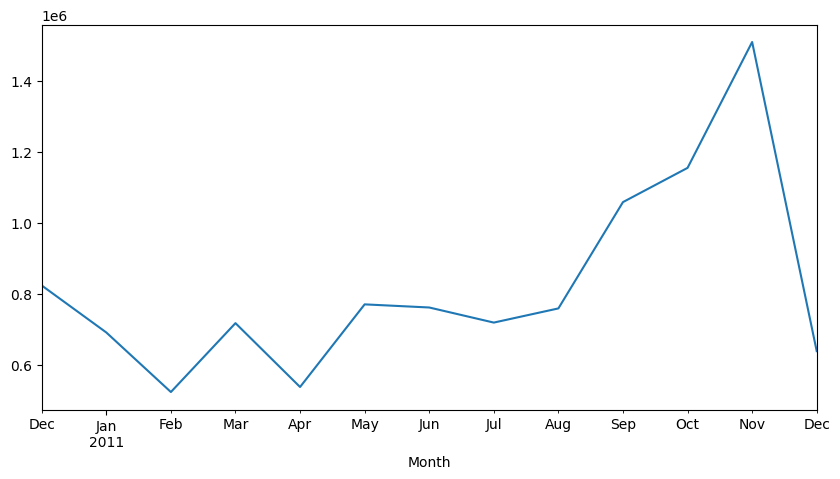

In [18]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby ('Month') ["Revenue"].sum()

monthly_sales.plot(figsize = (10,5))
plt.show()

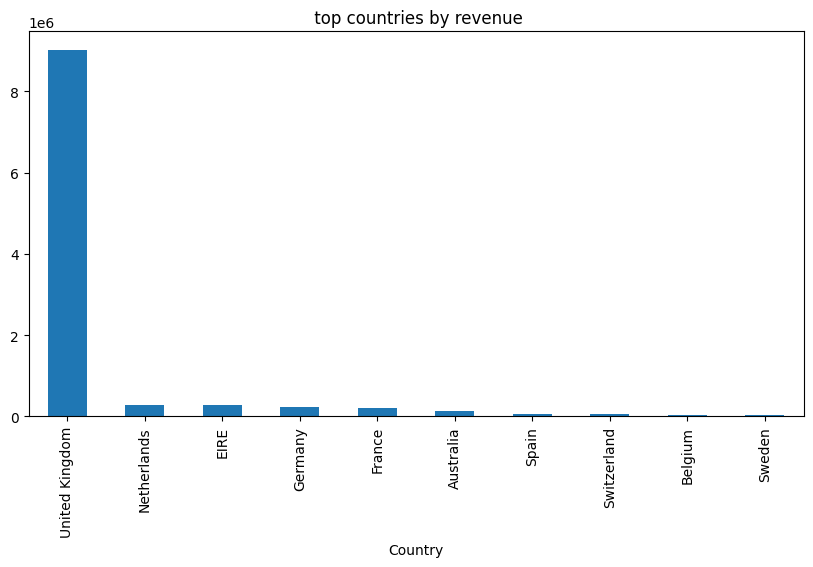

In [20]:
country_sales = df.groupby ("Country") ["Revenue"]. sum().sort_values(ascending = False).head(10)

country_sales.plot(kind = "bar", figsize= (10,5))
plt.title (" top countries by revenue")
plt.show()

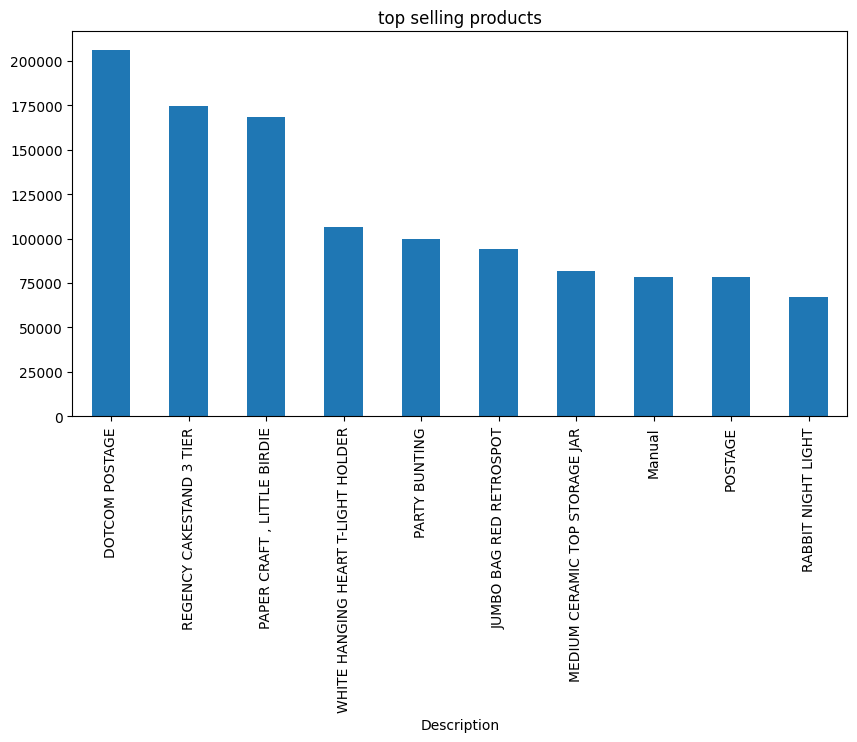

In [22]:
product_sales = df.groupby("Description") ["Revenue"].sum().sort_values (ascending = False).head(10)

product_sales.plot (kind = 'bar', figsize = (10,5))
plt.title ("top selling products")
plt.show()

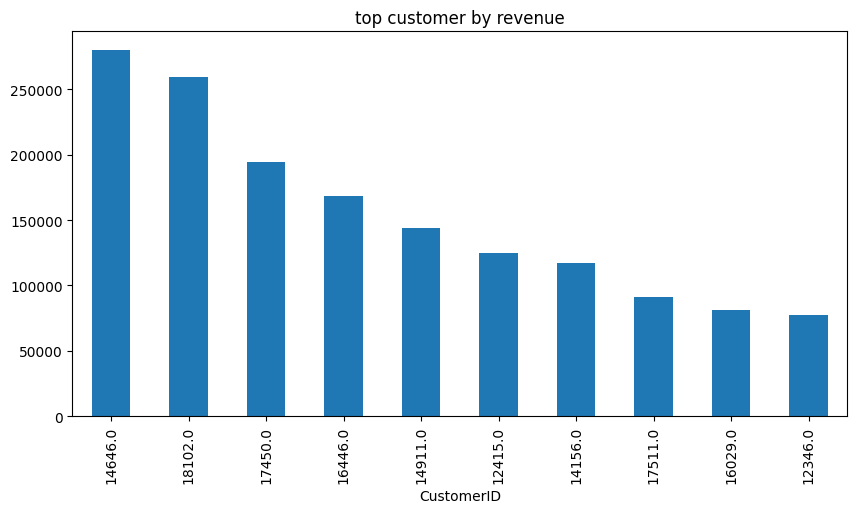

In [23]:
top_customer = df.groupby("CustomerID") ["Revenue"].sum().sort_values (ascending = False).head(10)

top_customer.plot (kind = 'bar', figsize = (10,5))
plt.title ("top customer by revenue")
plt.show()

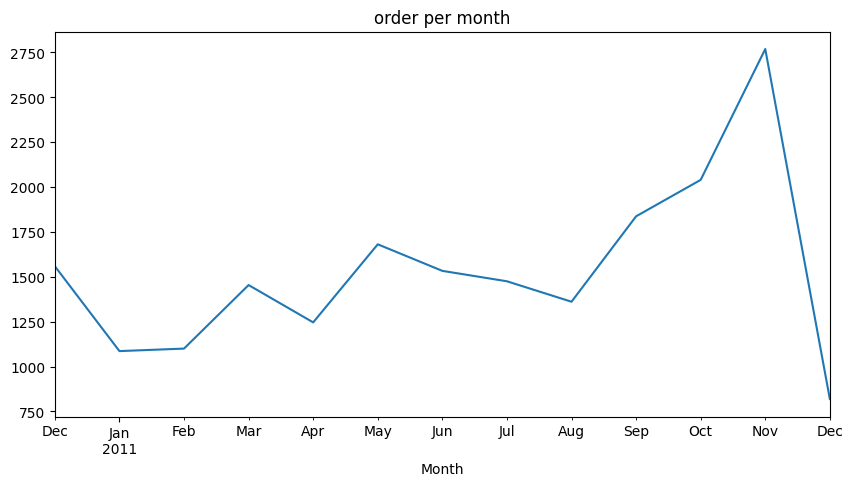

In [24]:
order_per_month = df.groupby("Month") ["InvoiceNo"].nunique()

order_per_month.plot(figsize = (10,5))
plt.title ("order per month")
plt.show()
           

In [25]:
order_total = df.groupby ("InvoiceNo") ["Revenue"].sum()
avg_order_value = order_total.mean()
avg_order_value

np.float64(534.403033266533)

In [26]:
print("Average order value:", avg_order_value)

Average order value: 534.403033266533
